# Explore here

In [11]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 1: Carga del conjunto de datos
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
# Nota: A veces estos datasets usan punto y coma como separador, probaremos con el separador por defecto (coma) o punto y coma.
try:
    df = pd.read_csv(url, sep=';')
    if len(df.columns) == 1: # Si lee todo como una sola columna, era por coma
        df = pd.read_csv(url, sep=',')
except:
    df = pd.read_csv(url, sep=',')

print("Datos cargados correctamente. Dimensiones del dataset:", df.shape)
df.head() # Muestra las primeras 5 filas


Datos cargados correctamente. Dimensiones del dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Valores nulos por columna:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


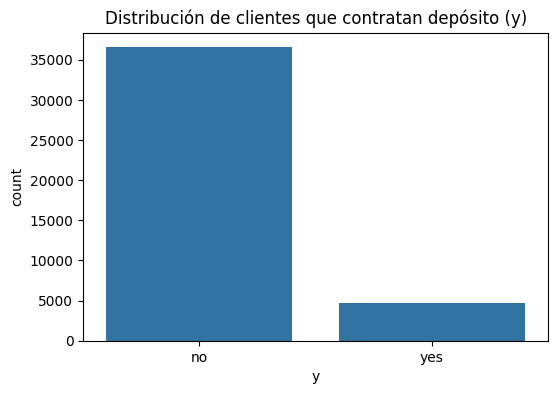

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [12]:
# Verificamos si hay valores nulos
print("Valores nulos por columna:\n", df.isnull().sum())

# Vemos la distribución de nuestra variable objetivo 'y' (si contratan o no)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')
plt.title("Distribución de clientes que contratan depósito (y)")
plt.show()

print("\nTipos de datos en el dataset:\n", df.info())

In [13]:
from sklearn.model_selection import train_test_split

# 1. Convertimos la variable objetivo 'y' a 1 y 0
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Convertimos el resto de variables categóricas (texto) a números usando "One-Hot Encoding"
# Esto crea columnas nuevas con 1s y 0s para cada categoría (ej. job_admin, marital_married)
X = pd.get_dummies(df.drop('y', axis=1), drop_first=True)
y = df['y']

# 3. Dividimos en Train y Test (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos listos. Tamaño de X_train: {X_train.shape}")

Datos listos. Tamaño de X_train: (32950, 53)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Creamos el modelo (ponemos max_iter=1000 para que tenga tiempo de hacer los cálculos matemáticos sin dar error)
model = LogisticRegression(max_iter=1000)

# 2. Lo entrenamos con los datos de Train
model.fit(X_train, y_train)

# 3. Hacemos predicciones con los datos de Test (los que el modelo nunca ha visto)
y_pred = model.predict(X_test)

# 4. Evaluamos qué tan bien lo hizo
print("--- RESULTADOS DEL MODELO BASE ---")
print(f"Precisión global (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte detallado:\n", classification_report(y_test, y_pred))

--- RESULTADOS DEL MODELO BASE ---
Precisión global (Accuracy): 0.9105

Matriz de Confusión:
 [[7108  195]
 [ 542  393]]

Reporte detallado:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Escalamos los datos (es vital para la Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Creamos un modelo OPTIMIZADO: le decimos que "balancee" la importancia de los Sí y los No
model_optimized = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')

# 3. Entrenamos con los datos escalados
model_optimized.fit(X_train_scaled, y_train)

# 4. Predecimos y evaluamos de nuevo
y_pred_opt = model_optimized.predict(X_test_scaled)

print("--- RESULTADOS DEL MODELO OPTIMIZADO ---")
print(f"Precisión global (Accuracy): {accuracy_score(y_test, y_pred_opt):.4f}")
print("\nReporte detallado Optimizado:\n", classification_report(y_test, y_pred_opt))

--- RESULTADOS DEL MODELO OPTIMIZADO ---
Precisión global (Accuracy): 0.8615

Reporte detallado Optimizado:
               precision    recall  f1-score   support

           0       0.98      0.86      0.92      7303
           1       0.45      0.89      0.59       935

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.76      8238
weighted avg       0.92      0.86      0.88      8238



Conclusión del Modelo:
Tras optimizar el modelo de Regresión Logística balanceando las clases (class_weight='balanced'), hemos logrado un modelo ideal para la campaña de marketing.

Nuestro objetivo de negocio era identificar a los clientes con mayor probabilidad de contratar un depósito para enfocar los esfuerzos de llamadas. El modelo optimizado alcanza un Recall del 89% para la clase positiva (1). Esto garantiza que el equipo de ventas contactará a 9 de cada 10 clientes dispuestos a comprar. Aunque la precisión es del 45%, este trade-off es altamente rentable para el banco, ya que el costo de realizar llamadas adicionales es mínimo frente al beneficio de captar casi todos los depósitos a largo plazo posibles.